<div style="display: flex; align-items: center;">
    <h1>Replacing WOFOST72 partitioning with a trainable neural network</h1>
    <img src="https://raw.githubusercontent.com/WUR-AI/diffWOFOST/refs/heads/main/docs/logo/diffwofost.png" width="150" style="margin-left: 20px;">
</div>

This notebook shows how to replace one internal component of <code>Wofost72</code> with a user-defined neural network while keeping the rest of the crop model unchanged.

The example replaces <code>self.part</code>, the **partitioning** component, with a neural module that predicts the four partitioning factors from the crop development stage <code>DVS</code>.

The workflow is:

1. Define a PyTorch network that outputs valid partitioning fractions.
2. Wrap that network in a small <code>SimulationObject</code> so it exposes the same interface as the built-in partitioning module.
3. Subclass <code>Wofost72</code> and swap <code>self.part</code> during initialization.
4. Optimize the neural network weights end to end against a reference <code>LAI</code> trajectory.

## 1. Software requirements

Install the latest version of <code>diffwofost</code>. This notebook also uses <code>matplotlib</code> for plotting.

In [1]:
# install required packages
!pip install diffwofost matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import copy
import urllib.request
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from pcse.base import SimulationObject
from pcse.traitlets import Instance

from diffwofost.physical_models.base import TensorStatesTemplate
from diffwofost.physical_models.config import Configuration, ComputeConfig
from diffwofost.physical_models.crop.partitioning import PartioningFactors
from diffwofost.physical_models.crop.wofost72 import Wofost72
from diffwofost.physical_models.soil.classic_waterbalance import WaterbalancePP
from diffwofost.physical_models.traitlets import Tensor
from diffwofost.physical_models.utils import EngineTestHelper
from diffwofost.physical_models.utils import get_test_data
from diffwofost.physical_models.utils import prepare_engine_input

warnings.filterwarnings("ignore", message="To copy construct from a tensor.*")
ComputeConfig.set_device("cpu")
ComputeConfig.set_dtype(torch.float64)

## 2. Load a reference WOFOST72 dataset

We use one of the standard PCSE WOFOST72 potential production test cases. The reference <code>LAI</code> series from the YAML file is the optimization target.

The same dataset is also run once with the default rule-based partitioning module so we can compare the learned partitioning fractions against the original WOFOST behavior.

In [3]:
filename = "test_potentialproduction_wofost72_03.yaml"
url = f"https://raw.githubusercontent.com/ajwdewit/pcse/refs/heads/master/tests/test_data/{filename}"

if not Path(filename).exists():
    urllib.request.urlretrieve(url, filename)

print(f"Using data file: {filename}")

Using data file: test_potentialproduction_wofost72_03.yaml


In [4]:
test_data = get_test_data(filename)

crop_model_params = [
    "SPAN",
    "TDWI",
    "TBASE",
    "PERDL",
    "RGRLAI",
    "KDIFTB",
    "SLATB",
    "TSUMEM",
    "TBASEM",
    "TEFFMX",
    "TSUM1",
    "TSUM2",
    "DLO",
    "DLC",
    "DVSI",
    "DVSEND",
    "DTSMTB",
    "AMAXTB",
    "EFFTB",
    "TMPFTB",
    "TMNFTB",
    "Q10",
    "RMR",
    "RML",
    "RMS",
    "RMO",
    "RFSETB",
    "CFET",
    "DEPNR",
    "IAIRDU",
    "IOX",
    "CRAIRC",
    "SM0",
    "SMW",
    "SMFCF",
    "RDI",
    "RRI",
    "RDMCR",
    "RDMSOL",
    "RDRRTB",
    "RDRSTB",
    "SSATB",
    "SPA",
    "FRTB",
    "FLTB",
    "FSTB",
    "FOTB",
    "CVL",
    "CVO",
    "CVR",
    "CVS",
]

(crop_model_params_provider, weather_data_provider, agro_management_inputs, external_states) = (
    prepare_engine_input(test_data, crop_model_params)
)

expected_lai = torch.tensor(
    [float(item["LAI"]) for item in test_data["ModelResults"]],
    dtype=ComputeConfig.get_dtype(),
    device=ComputeConfig.get_device(),
)

reference_config = Configuration(
    CROP=Wofost72,
    SOIL=WaterbalancePP,
    OUTPUT_VARS=["DVS", "LAI", "FR", "FL", "FS", "FO"],
)

print(f"Number of time steps: {expected_lai.numel()}")

Number of time steps: 280


## 3. Define the NN replacement of partitioning.py

Before replacing the partitioning module, let's recap its role in wofost72: 

- paritioning uses `DVS` to compute <code>FR</code>, <code>FL</code>, <code>FS</code> and <code>FO</code> 
- it publishes the new variables to the kiosk
- its <code>calc_rates()</code> returns a <code>PartioningFactors</code> tuple
- its <code>integrate()</code> updates the state variables for the new day

So we have to design a neural network that does the exact same things. Unfortunately a plain MLP is too simple and will not work in this situation, so we have designed instead a slightly more complicated network.
This network has two parts:

1. <b>One hidden layer trunk</b>
   The model takes raw <code>DVS</code>, reshapes it to a single input feature, and passes it through one hidden layer with a <code>SiLU</code> activation. This gives a smooth nonlinear mapping while staying close to the simplest possible MLP.

2. <b>Two linear output heads</b>
   The partitioning problem is not fully symmetric: <code>FR</code> controls below-ground allocation, while <code>FL</code>, <code>FS</code> and <code>FO</code> describe the split of the above-ground biomass. The model reflects that by using:
   - one linear head for <code>FR</code>
   - one linear head for the above-ground split <code>FL</code>, <code>FS</code>, <code>FO</code>

The output constraints are enforced directly:

- the <code>FR</code> head goes through a sigmoid, so <code>0 ≤ FR ≤ 1</code>
- the shoot head goes through a softmax, so <code>FL + FS + FO = 1</code>

That preserves the WOFOST partitioning identity <code>FR + (FL + FS + FO) * (1 - FR) = 1</code> by construction.

So now we define <code>PartitioningNN</code>, the neural network backbone of our trainable module:

In [5]:
class PartitioningNN(torch.nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()

        self.trunk = torch.nn.Sequential(
            torch.nn.Linear(1, hidden_size),
            torch.nn.SiLU(),
        )
        self.fr_head = torch.nn.Linear(hidden_size, 1)
        self.shoot_head = torch.nn.Linear(hidden_size, 3)

        with torch.no_grad():
            torch.nn.init.xavier_uniform_(self.trunk[0].weight)
            self.trunk[0].bias.zero_()
            self.fr_head.weight.normal_(mean=0.0, std=1e-2)
            self.fr_head.bias.fill_(-1.4)
            self.shoot_head.weight.normal_(mean=0.0, std=1e-2)
            self.shoot_head.bias.copy_(
                torch.tensor(
                    [2.0, 0.0, -3.0],
                    dtype=ComputeConfig.get_dtype(),
                    device=ComputeConfig.get_device(),
                )
            )

        self.to(device=ComputeConfig.get_device(), dtype=ComputeConfig.get_dtype())

    def forward(self, dvs):
        dvs = torch.as_tensor(
            dvs,
            dtype=ComputeConfig.get_dtype(),
            device=ComputeConfig.get_device(),
        )
        is_scalar = dvs.ndim == 0
        if is_scalar:
            dvs = dvs.unsqueeze(0)

        features = dvs.unsqueeze(-1)
        latent = self.trunk(features)
        fr = torch.sigmoid(self.fr_head(latent)[..., 0])
        above_ground = torch.softmax(self.shoot_head(latent), dim=-1)

        if is_scalar:
            fr = fr.squeeze(0)
            above_ground = above_ground.squeeze(0)

        return PartioningFactors(
            FR=fr,
            FL=above_ground[..., 0],
            FS=above_ground[..., 1],
            FO=above_ground[..., 2],
        )

We still need a small adapter because <code>Wofost72</code> expects its partitioning component to be a PCSE <code>SimulationObject</code> that publishes variables to the kiosk. To avoid a separate top-level wrapper class, we embed that adapter directly inside <code>HybridWofost72</code>.

## 4. Swap the component inside <code>Wofost72</code>

The subclass below keeps the full original <code>Wofost72</code> implementation and only replaces <code>self.part</code> which corresponds to the partitioning module. Inside we also wrap the `PartitioningNN` to behave as a `SimulationObject`

In [6]:
class HybridWofost72(Wofost72):
    partition_net = None

    class PartitionAdapter(SimulationObject):
        partition_net = Instance(torch.nn.Module)

        class StateVariables(TensorStatesTemplate):
            FR = Tensor(-99.0)
            FL = Tensor(-99.0)
            FS = Tensor(-99.0)
            FO = Tensor(-99.0)
            PF = Instance(PartioningFactors)

        def initialize(self, day, kiosk, parvalues, partition_net, shape=None):
            self.kiosk = kiosk
            self.partition_net = partition_net

            pf = self._predict()
            self.states = self.StateVariables(
                self.kiosk,
                publish=["FR", "FL", "FS", "FO"],
                FR=pf.FR,
                FL=pf.FL,
                FS=pf.FS,
                FO=pf.FO,
                PF=pf,
                shape=shape,
            )

        def _predict(self):
            dvs = torch.as_tensor(
                self.kiosk["DVS"],
                dtype=ComputeConfig.get_dtype(),
                device=ComputeConfig.get_device(),
            )
            return self.partition_net(dvs)

        def calc_rates(self, day, drv):
            return self.states.PF

        def integrate(self, day, delt=1.0):
            pf = self._predict()
            self.states.FR = pf.FR
            self.states.FL = pf.FL
            self.states.FS = pf.FS
            self.states.FO = pf.FO
            self.states.PF = pf

    def initialize(self, day, kiosk, parvalues, shape=None):
        super().initialize(day, kiosk, parvalues, shape=shape)
        self.part._delete()
        self.part = self.PartitionAdapter(
            day, kiosk, parvalues, self.partition_net, shape=shape
        )

Now we run the hybrid crop model, while keeping `PartitioningNN` as a trainable PyTorch module. The optimizer can work directly on <code>partition_net.parameters()</code>.

In [7]:
def run_hybrid_wofost72(partition_net):
    HybridWofost72.partition_net = partition_net
    hybrid_config = Configuration(
        CROP=HybridWofost72,
        SOIL=WaterbalancePP,
        OUTPUT_VARS=["DVS", "LAI", "FR", "FL", "FS", "FO"],
    )

    engine = EngineTestHelper(
        copy.deepcopy(crop_model_params_provider),
        weather_data_provider,
        agro_management_inputs,
        hybrid_config,
        external_states,
    )
    engine.run_till_terminate()
    results = engine.get_output()

    return {
        "DVS": torch.stack([item["DVS"] for item in results]),
        "LAI": torch.stack([item["LAI"] for item in results]),
        "FR": torch.stack([item["FR"] for item in results]),
        "FL": torch.stack([item["FL"] for item in results]),
        "FS": torch.stack([item["FS"] for item in results]),
        "FO": torch.stack([item["FO"] for item in results]),
    }

You can see that it runs similarly to the original reference

In [8]:

def run_reference_wofost72():
    engine = EngineTestHelper(
        copy.deepcopy(crop_model_params_provider),
        weather_data_provider,
        agro_management_inputs,
        reference_config,
        external_states,
    )
    engine.run_till_terminate()
    results = engine.get_output()
    return {
        "DVS": torch.stack([item["DVS"] for item in results]),
        "LAI": torch.stack([item["LAI"] for item in results]),
        "FR": torch.stack([item["FR"] for item in results]),
        "FL": torch.stack([item["FL"] for item in results]),
        "FS": torch.stack([item["FS"] for item in results]),
        "FO": torch.stack([item["FO"] for item in results]),
    }

In [9]:
reference_results = run_reference_wofost72()
partition_net = PartitioningNN(hidden_size=64)

initial_results = run_hybrid_wofost72(partition_net)
initial_loss = torch.mean(torch.abs(initial_results["LAI"] - expected_lai))

print(f"Initial LAI MAE: {initial_loss.detach().item():.4f}")
print(f"Initial FR sample: {initial_results['FR'][10].detach().item():.4f}")

Initial LAI MAE: 5.9907
Initial FR sample: 0.1979


## 5. Optimize the neural partitioning block

The optimizer sees only the parameters of <code>PartitioningNN</code>, but gradients are computed through the complete hybrid crop model executed by the helper function above.

The training objective is a weighted relative MAE on <code>LAI</code>: time steps with larger reference receive more weight, and the error is normalized by the weighted magnitude of the target series.

The loop also uses adaptive learning-rate reduction, gradient clipping, and early stopping with best-weight restoration.

In [10]:
peak_lai = torch.max(expected_lai).clamp_min(1e-6)
loss_weights = 0.1 + expected_lai / peak_lai
loss_denom = torch.mean(loss_weights * torch.abs(expected_lai)).clamp_min(1e-6)

optimizer = torch.optim.Adam(partition_net.parameters(), lr=0.003)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=8, min_lr=1e-4
)

max_steps = 60
patience = 12
min_delta = 1e-4
best_loss = float("inf")
best_step = -1
best_state = copy.deepcopy(partition_net.state_dict())
loss_history = []

for step in range(max_steps):
    optimizer.zero_grad()
    predictions = run_hybrid_wofost72(partition_net)
    lai_loss = torch.mean(
        loss_weights * torch.abs(predictions["LAI"] - expected_lai)
    ) / loss_denom
    lai_loss.backward()
    torch.nn.utils.clip_grad_norm_(partition_net.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step(lai_loss.detach())

    loss_value = lai_loss.detach().cpu().item()
    loss_history.append(loss_value)

    if loss_value < best_loss - min_delta:
        best_loss = loss_value
        best_step = step
        best_state = copy.deepcopy(partition_net.state_dict())

    if step % 5 == 0:
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Step {step:03d} | Weighted relative LAI loss = {loss_value:.4f} | LR = {current_lr:.5f}"
        )

    if step - best_step >= patience:
        print(f"Early stopping at step {step:03d}")
        break

partition_net.load_state_dict(best_state)
trained_results = run_hybrid_wofost72(partition_net)
trained_loss = torch.mean(torch.abs(trained_results["LAI"] - expected_lai))
trained_weighted_loss = (
    torch.mean(loss_weights * torch.abs(trained_results["LAI"] - expected_lai)) / loss_denom
)
print(f"Best weighted relative LAI loss: {best_loss:.4f}")
print(f"Final weighted relative LAI loss: {trained_weighted_loss.detach().item():.4f}")
print(f"Final LAI MAE: {trained_loss.detach().item():.4f}")

Step 000 | Weighted relative LAI loss = 2.2884 | LR = 0.00300
Step 005 | Weighted relative LAI loss = 2.1572 | LR = 0.00300
Step 010 | Weighted relative LAI loss = 1.9858 | LR = 0.00300
Step 015 | Weighted relative LAI loss = 1.7574 | LR = 0.00300
Step 020 | Weighted relative LAI loss = 1.4169 | LR = 0.00300
Step 025 | Weighted relative LAI loss = 0.8653 | LR = 0.00300
Step 030 | Weighted relative LAI loss = 0.3545 | LR = 0.00300
Step 035 | Weighted relative LAI loss = 0.5473 | LR = 0.00300
Step 040 | Weighted relative LAI loss = 0.4415 | LR = 0.00150
Early stopping at step 042
Best weighted relative LAI loss: 0.3545
Final weighted relative LAI loss: 0.4028
Final LAI MAE: 0.6592


Let's plot some results: 

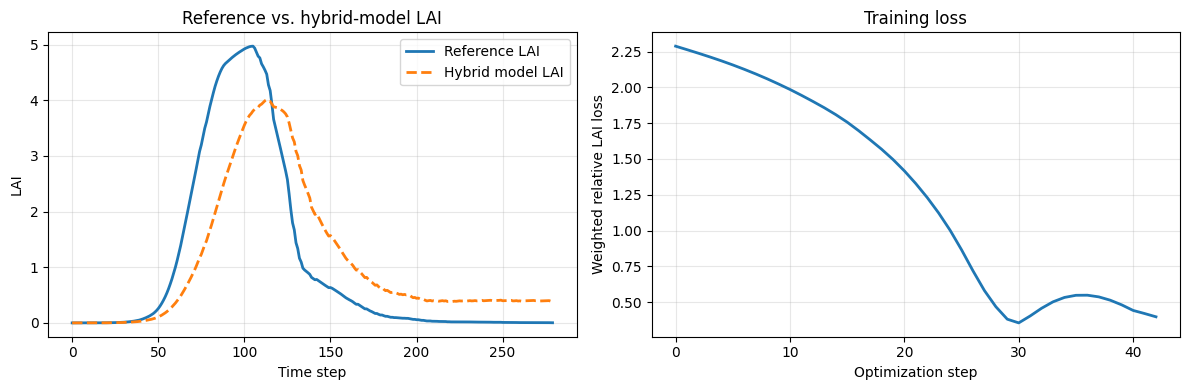

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(expected_lai.detach().cpu().numpy(), label="Reference LAI", linewidth=2)
axes[0].plot(
    trained_results["LAI"].detach().cpu().numpy(),
    label="Hybrid model LAI",
    linewidth=2,
    linestyle="--",
)
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("LAI")
axes[0].set_title("Reference vs. hybrid-model LAI")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(loss_history, linewidth=2)
axes[1].set_xlabel("Optimization step")
axes[1].set_ylabel("Weighted relative LAI loss")
axes[1].set_title("Training loss")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Inspect the learned partitioning curves

The next plot compares the neural partitioning fractions with the default WOFOST72 partitioning module.

This is not the training target in this notebook. It is only a diagnostic that helps you see how the neural replacement differs from the original process representation while still fitting the observed <code>LAI</code>.

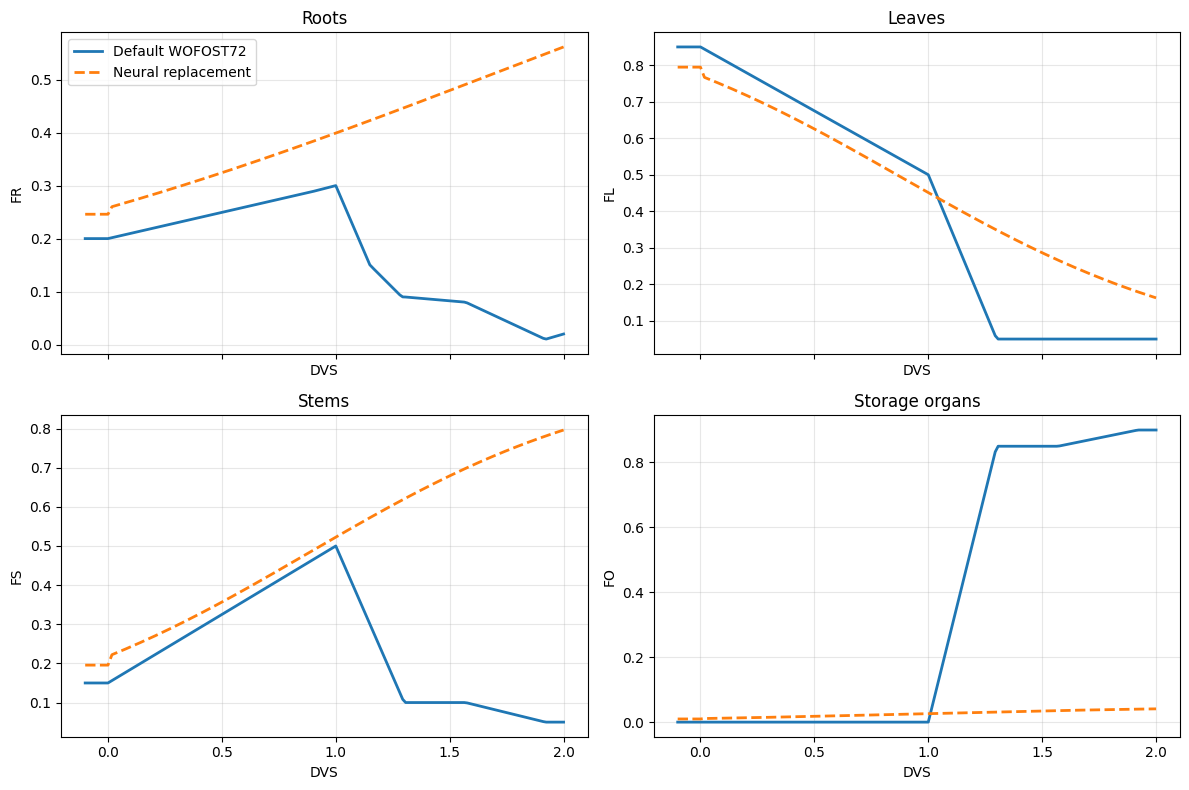

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
curves = [
    ("FR", "Roots"),
    ("FL", "Leaves"),
    ("FS", "Stems"),
    ("FO", "Storage organs"),
]

for ax, (varname, title) in zip(axes.ravel(), curves, strict=False):
    ax.plot(
        reference_results["DVS"].detach().cpu().numpy(),
        reference_results[varname].detach().cpu().numpy(),
        label="Default WOFOST72",
        linewidth=2,
    )
    ax.plot(
        trained_results["DVS"].detach().cpu().numpy(),
        trained_results[varname].detach().cpu().numpy(),
        label="Neural replacement",
        linewidth=2,
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlabel("DVS")
    ax.set_ylabel(varname)
    ax.grid(alpha=0.3)

axes[0, 0].legend()
plt.tight_layout()
plt.show()

You can see that the neural replacement that we have trained in this notebook does not fully reproduce the default behavior, but it is good enough for the single example that we have used for training as you can see in the previous plot.

## 7. Recap

You can reuse the same pattern shown here for other internal WOFOST components, not only partitioning.

The general recipe is:

1. identify the module you want to replace and the variables it reads from the kiosk
2. define a small PyTorch model that maps those inputs to the outputs that module is supposed to provide
3. wrap the network in a <code>SimulationObject</code> so it exposes the same methods and publishes the same state variables
4. subclass the crop model and swap the original component for your custom one during initialization
5. choose a training target, run the hybrid model end to end, and optimize only the neural-network parameters

The main thing to preserve is compatibility with the rest of the simulation: if your replacement publishes the right variables and follows the same calling pattern, you can usually test the effect of a neural alternative without rewriting the rest of the crop model.